# SpeechT5 + WavLM Fine-Tuning

This notebook fine-tunes **SpeechT5** (`microsoft/speecht5_vc`) to accept **WavLM hidden states**
as encoder input instead of raw audio, enabling a WavLM-based feature-space speech translation pipeline.

## Architecture
```
EN raw audio  ──► [WavLM Encoder (frozen)]  ──► EN hidden states (Seq, 768)
                                                        │
                                 [SpeechT5 Transformer (fine-tuned)] ──► DE mel spectrogram
                                                        │
                                             [HiFi-GAN Vocoder]  ──► DE audio
```

## Required Pre-Step
The preprocessed WavLM dataset must exist at:
```
datasets/processed_wavlm_en_de_v1/
    en/   ← WavLM hidden states (Seq, 768)
    de/   ← WavLM hidden states (Seq, 768)
```
Run `preprocess_wavlm.py` if the dataset is not yet generated.

> **Note on the target representation:**  
> The dataset stores WavLM features for both sides. The `SpeechT5WavLMDataset`
> class in `model.py` handles the fallback to mel-spectrogram extraction if the
> target is raw audio. The fine-tuning loss is computed against SpeechT5's
> mel-spectrogram decoder output — this is what teaches the model to bridge
> the WavLM representation into something the trained decoder can process.


## 1. Setup & Imports

In [17]:
import os
import sys

# Add project root to Python path so that dataset_loader and encoders are importable.
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, project_root)

from model import SpeechT5WavLM
import dataset_loader
from datasets import load_from_disk
import numpy as np
from IPython.display import Audio, display

print(f"Project root: {project_root}")
print(f"Datasets directory: {dataset_loader.DATASETS_DIR}")

Project root: /media/zawiatgf/New Volume/Personal Files/Abdurrahman Zawia/University/Grad Project/Speech-To-Speech-Model
Datasets directory: /media/zawiatgf/New Volume/Personal Files/Abdurrahman Zawia/University/Grad Project/Speech-To-Speech-Model/datasets


## 2. Configuration

Edit the constants below to control training behaviour.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Path to the preprocessed WavLM dataset produced by preprocess_wavlm.py.
# ─────────────────────────────────────────────────────────────────────────────
PREPROCESSED_PATH = os.path.join(dataset_loader.DATASETS_DIR, "processed_wavlm_en_de_v8")

# ─────────────────────────────────────────────────────────────────────────────
# Training hyper-parameters
# ─────────────────────────────────────────────────────────────────────────────
EPOCHS        = 5       # Total training epochs
BATCH_SIZE    = 1        # Keep small — WavLM sequences are variable length
LEARNING_RATE = 2e-5     # Low LR for stable fine-tuning of pre-trained weights

# ─────────────────────────────────────────────────────────────────────────────
# Output checkpoint directory
# ─────────────────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "speecht5_wavlm_en_de_v2026_05_11"

print(f"Preprocessed data: {PREPROCESSED_PATH}")
print(f"Epochs: {EPOCHS}  |  Batch size: {BATCH_SIZE}  |  LR: {LEARNING_RATE}")
print(f"Checkpoint will be saved to: {CHECKPOINT_DIR}")

Preprocessed data: /media/zawiatgf/New Volume/Personal Files/Abdurrahman Zawia/University/Grad Project/Speech-To-Speech-Model/datasets/processed_wavlm_en_de_v8
Epochs: 5  |  Batch size: 1  |  LR: 2e-05
Checkpoint will be saved to: speecht5_wavlm_en_de_v2026_05_11


## 4. Initialise the Model

`SpeechT5WavLM` loads:
- **SpeechT5** (`microsoft/speecht5_vc`) — the transformer to fine-tune
- **HiFi-GAN** (`microsoft/speecht5_hifigan`) — the vocoder (frozen, used at inference)

WavLM itself is **not** loaded here; it was already used during preprocessing to produce the
hidden states stored in the dataset. It is only needed again at inference time
(handled by `run_inference`).

In [19]:
model = SpeechT5WavLM()
# model.load("speecht5_wavlm_en_de_v2026_05_11_001")
print(f"\nModel loaded on device: {model.device}")

Loading SpeechT5WavLM components (WavLM=microsoft/wavlm-base-plus)...
Using device: cuda

Model loaded on device: cuda


## 4.5 Overfitting Test (Single Sample)

This cell takes exactly one sample from the preprocessed dataset and runs many epochs to ensure the model can achieve near-zero loss on it. This is a critical diagnostic step to verify that the architecture is capable of memorizing data before running a full training session.

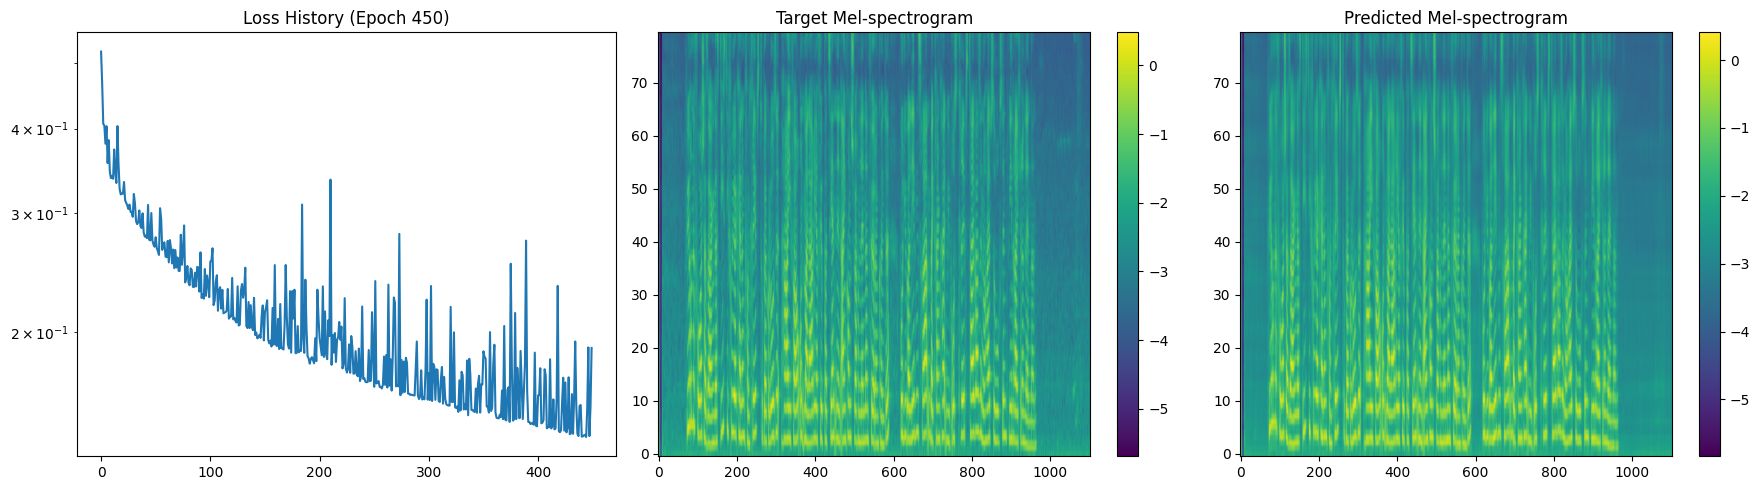

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import torch
import os
import shutil
from datasets import load_from_disk
from tqdm import tqdm
import numpy as np

# --- 1. Configuration & Data Preparation ---
OVERFIT_TEMP_DIR = "temp_overfit_dataset"
if os.path.exists(OVERFIT_TEMP_DIR):
    shutil.rmtree(OVERFIT_TEMP_DIR)

print(f"Loading dataset from {PREPROCESSED_PATH}...")
full_dataset = load_from_disk(PREPROCESSED_PATH)
single_sample = full_dataset.select([1])
single_sample.save_to_disk(OVERFIT_TEMP_DIR)

# Extract speaker embedding if needed
if model.target_embeddings is None:
    model.get_speaker_embedding("de")

# --- 2. Deterministic State Setup ---
model.train()
# Force dropout to eval mode for memorization
for m in model.model.modules():
    if "Dropout" in m.__class__.__name__:
        m.eval()
model.model.freeze_feature_encoder()

# --- 3. Optimizer Setup ---
learning_rate = 1e-5 # Slightly higher for quicker visual feedback in overfit
trainable_params = (
    list(filter(lambda p: p.requires_grad, model.model.parameters())) +
    list(model.wavlm_proj.parameters())
)
optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate)
l1_criterion = torch.nn.L1Loss(reduction="none")
mse_criterion = torch.nn.MSELoss(reduction="none")

# --- 4. Overfitting Loop with Visualization ---
EPOCHS = 500
VIZ_EVERY = 50
loss_history = []

# Prepare data for the loop (manual batching for simplicity)
# Note: Accessing model.fine_tune.__globals__ to get Dataset and Collate function
dataset_class = model.fine_tune.__globals__['SpeechT5WavLMDataset']
collate_fn = model.fine_tune.__globals__['wavlm_speecht5_collate_fn']

batch = next(iter(torch.utils.data.DataLoader(
    dataset_class(single_sample, model.processor, model.target_embeddings),
    batch_size=1,
    collate_fn=collate_fn
)))

input_values, attention_mask, labels, speaker_embeddings = [t.to(model.device) for t in batch]

print("Starting Overfitting with Real-time Visualization...")

try:
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        
        # Forward pass
        encoder_out = model._encode_wavlm_states(input_values, attention_mask)
        from transformers.models.speecht5.modeling_speecht5 import shift_spectrograms_right
        decoder_input_values, decoder_attention_mask = shift_spectrograms_right(
            labels, model.model.config.reduction_factor, None
        )
        
        outputs = model.model.speecht5(
            encoder_outputs=encoder_out,
            attention_mask=attention_mask,
            decoder_input_values=decoder_input_values,
            decoder_attention_mask=decoder_attention_mask,
            speaker_embeddings=speaker_embeddings,
            use_cache=False,
            return_dict=True,
        )
        
        outputs_before_postnet, outputs_after_postnet, stop_logits = (
            model.model.speech_decoder_postnet(outputs.last_hidden_state)
        )
        
        # Loss calculation (Matching model.py logic)
        T_tgt = labels.shape[1]
        pred_after = outputs_after_postnet[:, :T_tgt, :]
        valid_mask = (labels != -100.0).any(dim=-1).unsqueeze(-1).float()
        num_valid_elements = valid_mask.sum() * 80.0
        
        l1_post = l1_criterion(pred_after, labels) * valid_mask
        mse_post = mse_criterion(pred_after, labels) * valid_mask
        loss = (l1_post.sum() + mse_post.sum()) / num_valid_elements
        
        loss.backward()
        optimizer.step()
        
        loss_val = loss.item()
        loss_history.append(loss_val)
        
        # --- Visualization ---
        if (epoch + 1) % VIZ_EVERY == 0 or epoch == 0:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # 1. Loss Plot
            axes[0].plot(loss_history)
            axes[0].set_title(f"Loss History (Epoch {epoch+1})")
            axes[0].set_yscale('log')
            
            # 2. Target Spectrogram
            target_mel = labels[0].cpu().numpy()
            target_mel[target_mel == -100] = np.nan # Mask padding
            im1 = axes[1].imshow(target_mel.T, origin='lower', aspect='auto')
            axes[1].set_title("Target Mel-spectrogram")
            plt.colorbar(im1, ax=axes[1])
            
            # 3. Predicted Spectrogram
            pred_mel = pred_after[0].detach().cpu().numpy()
            im2 = axes[2].imshow(pred_mel.T, origin='lower', aspect='auto')
            axes[2].set_title("Predicted Mel-spectrogram")
            plt.colorbar(im2, ax=axes[2])
            
            plt.tight_layout()
            plt.show()
            
    print("Overfitting complete.")

except KeyboardInterrupt:
    print("Interrupted.")

## 5. Extract Target Speaker Embedding

The SpeechT5 decoder needs an **x-vector speaker embedding** to condition its output voice.

`get_speaker_embedding` streams one sample from Google FLEURS for the target language and
computes the x-vector using the SpeechBrain classifier. The embedding is saved alongside
the model checkpoint.

In [4]:
model.get_speaker_embedding(target_lang="de")

Initializing X-Vector classifier for embedding extraction...


/media/zawiatgf/New Volume/Personal Files/Abdurrahman Zawia/University/Grad Project/Speech-To-Speech-Model/.venv/lib/python3.12/site-packages/speechbrain/utils/autocast.py:188: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)


Extracting target speaker embedding...
Embedding extracted successfully.


## 6. Fine-Tune

Training will:
1. Load the preprocessed WavLM dataset.
2. Freeze SpeechT5's CNN feature encoder (only transformer layers are trained).
3. Feed WavLM hidden states directly into SpeechT5's transformer encoder.
4. Compute the spectrogram loss against the decoder's mel output.
5. Save a checkpoint every 5 epochs. On `KeyboardInterrupt` progress is saved
   automatically to `speecht5_wavlm_interrupted`.

In [ ]:
model.fine_tune(
    preprocessed_path=PREPROCESSED_PATH,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
)

## 7. Save the Final Checkpoint

In [ ]:
model.save(CHECKPOINT_DIR)
print(f"Model saved to: {CHECKPOINT_DIR}")

## 8. Quick Inference Test

Load a raw EN clip from the raw dataset and run it through the full pipeline
(WavLM → fine-tuned SpeechT5 transformer → HiFi-GAN) to hear if the model is learning.

In [16]:
source_lang = "en"
target_lang = "de"
# model.load("speecht5_wavlm_en_de_v2026_05_11_001")
# Load a raw EN sample from the seamless_align dataset for inference.
print("Loading a raw EN sample for inference test...")
raw = dataset_loader.load_data(
    lang=[source_lang],
    split="train",
    dataset=["fleurs"],
    num_samples=1000,
)
sample = raw[source_lang][6]
audio_array = np.array(sample['audio']['array'], dtype=np.float32)
sr = sample['audio']['sampling_rate']

print(f"Input audio: {len(audio_array)/sr:.2f}s @ {sr}Hz")
print("Original EN audio:")
display(Audio(data=audio_array, rate=sr))

# Run the full pipeline: raw audio → WavLM → fine-tuned SpeechT5 → HiFi-GAN → audio
print("\nRunning fine-tuned inference...")
result = model.run_inference(
    audio_array=audio_array,
    sampling_rate=sr,
    threshold=0.5,
    minlenratio=0.0,
    maxlenratio=2.0,
)

out_audio = result['audio']['array']
out_sr    = result['audio']['sampling_rate']

print(f"Output audio: {len(out_audio)/out_sr:.2f}s @ {out_sr}Hz")
print("\nGenerated DE audio (after fine-tuning):")
display(Audio(data=out_audio, rate=out_sr))

Loading a raw EN sample for inference test...
Loading google/fleurs (en_us) from local storage...
Validating en (audio & uniqueness)...
Final Count: 1476 common valid samples.
Input audio: 9.12s @ 16000Hz
Original EN audio:



Running fine-tuned inference...
Output audio: 14.56s @ 16000Hz

Generated DE audio (after fine-tuning):


## Bonus: Resume Training from a Checkpoint

If training was interrupted, load the saved checkpoint and continue.

In [ ]:
# ── Uncomment to resume from a saved checkpoint ──────────────────────────────
# RESUME_CHECKPOINT = "speecht5_wavlm_en_de_v2"
# model = SpeechT5WavLM()
# model.load(RESUME_CHECKPOINT)
# model.fine_tune(
#     preprocessed_path=PREPROCESSED_PATH,
#     epochs=EPOCHS,
#     learning_rate=LEARNING_RATE,
#     batch_size=BATCH_SIZE,
# )

## 9. Diagnostic Check: Teacher-Forced Forward Pass

This cell runs a standard training forward pass (using teacher forcing) and passes the predicted mel-spectrogram to the vocoder. If it sounds like speech, the cross-attention alignment is working, and the previous mode-collapse was solely due to the inference loop lacking dropout. If it sounds like a continuous drone, cross-attention alignment has failed.

In [ ]:
import torch
from torch.utils.data import DataLoader
from datasets import load_from_disk
from transformers.models.speecht5.modeling_speecht5 import shift_spectrograms_right
from IPython.display import Audio, display
from model import SpeechT5WavLMDataset, wavlm_speecht5_collate_fn

# 1. Put model in eval mode
model.model.eval()
model.vocoder.eval()
model.wavlm_proj.eval()

# 2. Load dataset and get one batch
paired_ds = load_from_disk(PREPROCESSED_PATH)
train_dataset = SpeechT5WavLMDataset(paired_ds, model.processor, model.target_embeddings)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=wavlm_speecht5_collate_fn)

batch = next(iter(train_loader))
input_values, attention_mask, labels, speaker_embeddings = batch
input_values = input_values.to(model.device)
attention_mask = attention_mask.to(model.device).long()
labels = labels.to(model.device)
speaker_embeddings = speaker_embeddings.to(model.device)

print("Running Teacher-Forced Forward Pass...")
with torch.no_grad():
    # Encode WavLM states
    encoder_out = model._encode_wavlm_states(input_values, attention_mask)
    
    # Shift targets for teacher forcing
    decoder_input_values, decoder_attention_mask = shift_spectrograms_right(
        labels, model.model.config.reduction_factor, None
    )
    
    # Forward pass through SpeechT5
    outputs = model.model.speecht5(
        encoder_outputs=encoder_out,
        attention_mask=attention_mask,
        decoder_input_values=decoder_input_values,
        decoder_attention_mask=decoder_attention_mask,
        speaker_embeddings=speaker_embeddings,
        use_cache=False,
        return_dict=True,
    )
    
    # Postnet projection
    _, outputs_after_postnet, _ = model.model.speech_decoder_postnet(outputs.last_hidden_state)
    
    # Take the predicted mel from the first item in the batch
    predicted_mel = outputs_after_postnet[0]
    
    # Generate audio with vocoder
    print("Vocoding predicted mel-spectrogram...")
    speech = model.vocoder(predicted_mel).squeeze()
    
audio_arr = speech.cpu().numpy()
print("Done! Listen below:")
display(Audio(audio_arr, rate=16000))
